# Detecção de Anomalias em Transações em Python

## Sobre o projeto

Projeto educacional desenvolvido no bootcamp **Bradesco – GenAI, Dados & Cyber**, da **DIO**, com base nas aulas de **Detecção de Anomalias em Transações em Python**, ministradas pela professora **Dra. Isadora Garcia Ferrão**.

Embora o desafio utilize o termo “anomalias”, este notebook trabalha com **classificação supervisionada de fraudes**, usando transações previamente rotuladas.

## Objetivo

Comparar abordagens de aprendizado de máquina para identificar transações fraudulentas, considerando o desbalanceamento das classes e a relação entre fraudes detectadas, fraudes não detectadas e falsos alarmes.

## Fonte dos dados

Foi utilizado o conjunto público **Credit Card Fraud Detection**, disponibilizado no Kaggle e associado à colaboração de pesquisa entre Worldline e o grupo de Machine Learning da Université Libre de Bruxelles (ULB), conforme descrito na [documentação do TensorFlow](https://www.tensorflow.org/tutorials/structured_data/imbalanced_data).

O notebook carrega uma [cópia do arquivo CSV hospedada pelo TensorFlow](https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv), utilizando Pandas.

A base original contém 284.807 registros e 31 colunas. A variável-alvo é `Class`:

- `0`: transação não fraudulenta.
- `1`: transação fraudulenta.

Os dados são públicos e não foram extraídos de sistemas do Bradesco ou de clientes atendidos pelo autor. TensorFlow é a referência de hospedagem do CSV, não a biblioteca utilizada para treinar os modelos deste projeto.

## Etapas do notebook

1. Carregamento e inspeção dos dados.
2. Auditoria e tratamento documentado das repetições completas.
3. Separação em treino, validação e teste.
4. Comparação entre uma referência simples e regressão logística.
5. Avaliação com curvas ROC e Precisão–Recall.
6. Experimentos com undersampling e SMOTE.
7. Treinamento de Random Forest e XGBoost.
8. Busca de configurações com validação cruzada.
9. Ajuste do limite de decisão na validação.
10. Avaliação final no teste reservado.
11. Importância das variáveis e explicabilidade com SHAP.
12. Discussão dos resultados e limitações.

## Adaptações em relação às aulas

Esta implementação inclui auditoria de duplicatas, validação separada para ajuste do limite, padronização e reamostragem restritas ao treino, seleção de configurações pela AP média e registro explícito das limitações.

Os resultados apresentados foram obtidos na execução deste notebook, não transcritos das demonstrações da professora.

## Tecnologias

Python, Pandas, NumPy, Matplotlib, scikit-learn, imbalanced-learn, XGBoost, SHAP e Google Colab.

> Material educacional. Os resultados não demonstram prontidão para operação bancária nem autorizam decisões automatizadas sobre transações reais.



In [1]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

df.head()

Linhas: 284807
Colunas: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Tipos das colunas e quantidade de valores preenchidos
df.info()

# Verificação de valores ausentes e linhas repetidas
print("\nTotal de valores ausentes:", df.isna().sum().sum())
print("Linhas completamente duplicadas:", df.duplicated().sum())

# Quantidade e percentual de cada classe
contagem = df["Class"].value_counts(dropna=False).sort_index()

resumo_classes = pd.DataFrame({
    "Quantidade": contagem,
    "Percentual (%)": (contagem / len(df) * 100).round(4)
})

print("\nDistribuição das classes:")
display(resumo_classes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Quantidade,Percentual (%)
Class,,
0,284315,99.8273
1,492,0.1727


In [3]:
# Marca apenas as repetições posteriores à primeira ocorrência
duplicadas = df.duplicated(keep="first")

# Compara as quantidades por classe
antes = df["Class"].value_counts().sort_index()
repeticoes = (
    df.loc[duplicadas, "Class"]
    .value_counts()
    .reindex(antes.index, fill_value=0)
)

auditoria_duplicatas = pd.DataFrame({
    "Quantidade original": antes,
    "Repetições adicionais": repeticoes,
    "Quantidade sem repetições": antes - repeticoes
})

display(auditoria_duplicatas)

print("\nTotal original:", len(df))
print("Total sem repetições:", len(df) - duplicadas.sum())

# Mostra exemplos, incluindo a primeira ocorrência de cada grupo
print("\nExemplos de linhas idênticas:")
display(
    df.loc[df.duplicated(keep=False)]
    .sort_values(["Time", "Amount"])
    .head(10)
)

,Quantidade original,Repetições adicionais,Quantidade sem repetições
Class,,,
0,284315,1062,283253
1,492,19,473



Total original: 284807
Total sem repetições: 283726

Exemplos de linhas idênticas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


In [4]:
# Cria uma base de trabalho sem linhas completamente repetidas
# O DataFrame original "df" permanece intacto
df_modelo = df.drop_duplicates(keep="first").copy()

print("Registros na base original:", len(df))
print("Registros na base de trabalho:", len(df_modelo))
print("Repetições removidas da cópia:", len(df) - len(df_modelo))
print("Duplicatas restantes:", df_modelo.duplicated().sum())

# Distribuição das classes após o tratamento
contagem_modelo = df_modelo["Class"].value_counts().sort_index()

resumo_modelo = pd.DataFrame({
    "Quantidade": contagem_modelo,
    "Percentual (%)": (
        contagem_modelo / len(df_modelo) * 100
    ).round(4)
})

display(resumo_modelo)

Registros na base original: 284807
Registros na base de trabalho: 283726
Repetições removidas da cópia: 1081
Duplicatas restantes: 0


,Quantidade,Percentual (%)
Class,,
0,283253,99.8333
1,473,0.1667


In [5]:
from sklearn.model_selection import train_test_split

# X contém as características; y contém a resposta esperada
X = df_modelo.drop(columns="Class")
y = df_modelo["Class"]

# Reserva 20% para o teste final
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Dos 80% restantes, separa 25% para validação:
# 25% de 80% = 20% da base total
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=42
)

# Confere os tamanhos e a distribuição das classes
resumo_divisao = pd.DataFrame([
    {
        "Conjunto": nome,
        "Registros": len(alvo),
        "Não fraudulentas": int((alvo == 0).sum()),
        "Fraudulentas": int((alvo == 1).sum()),
        "Fraudes (%)": round(alvo.mean() * 100, 4)
    }
    for nome, alvo in [
        ("Treino", y_train),
        ("Validação", y_val),
        ("Teste", y_test)
    ]
])

display(resumo_divisao)

# Verifica se alguma linha foi colocada em mais de um conjunto
assert X_train.index.intersection(X_val.index).empty
assert X_train.index.intersection(X_test.index).empty
assert X_val.index.intersection(X_test.index).empty
assert len(X_train) + len(X_val) + len(X_test) == len(df_modelo)

print("Verificações concluídas: conjuntos sem índices em comum.")

,Conjunto,Registros,Não fraudulentas,Fraudulentas,Fraudes (%)
0,Treino,170235,169951,284,0.1668
1,Validação,56745,56651,94,0.1657
2,Teste,56746,56651,95,0.1674


Verificações concluídas: conjuntos sem índices em comum.


In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Referência simples: sempre prevê a classe mais frequente
modelo_base = DummyClassifier(strategy="most_frequent")

# Primeiro modelo que aprende com as características
modelo_logistico = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])

modelos_iniciais = {
    "Sempre não fraudulenta": modelo_base,
    "Regressão logística": modelo_logistico
}

resultados_iniciais = []

for nome, modelo in modelos_iniciais.items():
    # Aprende somente com o treino
    modelo.fit(X_train, y_train)

    # Avalia somente na validação
    previsoes = modelo.predict(X_val)

    tn, fp, fn, tp = confusion_matrix(
        y_val, previsoes, labels=[0, 1]
    ).ravel()

    resultados_iniciais.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_val, previsoes),
        "Precisão (fraude)": precision_score(
            y_val, previsoes, zero_division=0
        ),
        "Recall (fraude)": recall_score(
            y_val, previsoes, zero_division=0
        ),
        "F1 (fraude)": f1_score(
            y_val, previsoes, zero_division=0
        ),
        "Fraudes detectadas": int(tp),
        "Fraudes não detectadas": int(fn),
        "Falsos alarmes": int(fp)
    })

comparacao_inicial = pd.DataFrame(resultados_iniciais)
display(comparacao_inicial.round(4))

,Modelo,Acurácia,Precisão (fraude),Recall (fraude),F1 (fraude),Fraudes detectadas,Fraudes não detectadas,Falsos alarmes
0,Sempre não fraudulenta,0.9983,0.0000,0.0000,0.0000,0,94,0
1,Regressão logística,0.9993,0.8767,0.6809,0.7665,64,30,9


ROC AUC — validação: 0.9733
Average Precision (AP) — validação: 0.8023


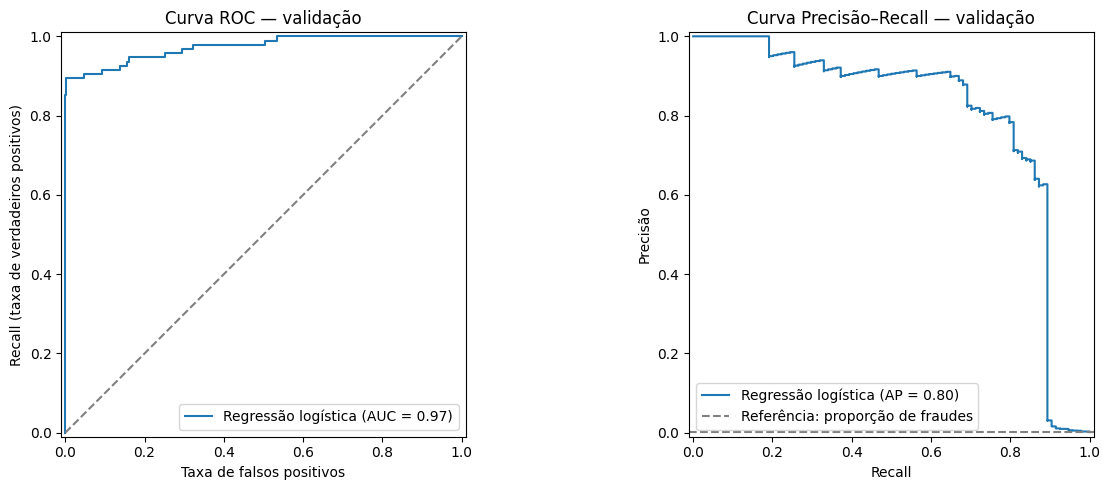

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
    average_precision_score
)

# Probabilidades da classe 1, geradas pela regressão logística
prob_logistica_val = modelo_logistico.predict_proba(X_val)[:, 1]

roc_auc_logistica = roc_auc_score(y_val, prob_logistica_val)
ap_logistica = average_precision_score(y_val, prob_logistica_val)

print(f"ROC AUC — validação: {roc_auc_logistica:.4f}")
print(f"Average Precision (AP) — validação: {ap_logistica:.4f}")

fig, eixos = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_val,
    prob_logistica_val,
    name="Regressão logística",
    ax=eixos[0]
)
eixos[0].plot([0, 1], [0, 1], "--", color="gray")
eixos[0].set_title("Curva ROC — validação")
eixos[0].set_xlabel("Taxa de falsos positivos")
eixos[0].set_ylabel("Recall (taxa de verdadeiros positivos)")

PrecisionRecallDisplay.from_predictions(
    y_val,
    prob_logistica_val,
    name="Regressão logística",
    ax=eixos[1]
)
eixos[1].axhline(
    y_val.mean(),
    linestyle="--",
    color="gray",
    label="Referência: proporção de fraudes"
)
eixos[1].set_title("Curva Precisão–Recall — validação")
eixos[1].set_xlabel("Recall")
eixos[1].set_ylabel("Precisão")
eixos[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

In [8]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Função reutilizável para avaliar modelos na mesma validação
def avaliar_validacao(nome, modelo):
    previsoes = modelo.predict(X_val)
    probabilidades = modelo.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_val, previsoes, labels=[0, 1]
    ).ravel()

    return {
        "Modelo": nome,
        "Precisão": precision_score(
            y_val, previsoes, zero_division=0
        ),
        "Recall": recall_score(
            y_val, previsoes, zero_division=0
        ),
        "F1": f1_score(y_val, previsoes, zero_division=0),
        "AP": average_precision_score(y_val, probabilidades),
        "ROC AUC": roc_auc_score(y_val, probabilidades),
        "Detectadas": int(tp),
        "Não detectadas": int(fn),
        "Falsos alarmes": int(fp)
    }

modelos_balanceamento = {}

for nome, amostrador in [
    ("Logística + undersampling",
     RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
    ("Logística + SMOTE",
     SMOTE(sampling_strategy=1.0, random_state=42))
]:
    modelos_balanceamento[nome] = ImbPipeline([
        ("scaler", StandardScaler()),
        ("amostrador", amostrador),
        ("modelo", LogisticRegression(
            max_iter=2000, random_state=42
        ))
    ])

# Inclui o modelo anterior, sem treiná-lo novamente
resultados_balanceamento = [
    avaliar_validacao("Logística original", modelo_logistico)
]

for nome, modelo in modelos_balanceamento.items():
    print(f"Treinando: {nome}...")
    modelo.fit(X_train, y_train)
    resultados_balanceamento.append(
        avaliar_validacao(nome, modelo)
    )

comparacao_balanceamento = pd.DataFrame(resultados_balanceamento)
display(comparacao_balanceamento.round(4))


Treinando: Logística + undersampling...
Treinando: Logística + SMOTE...


,Modelo,Precisão,Recall,F1,AP,ROC AUC,Detectadas,Não detectadas,Falsos alarmes
0,Logística original,0.8767,0.6809,0.7665,0.8023,0.9733,64,30,9
1,Logística + undersampling,0.0280,0.9149,0.0543,0.5167,0.9742,86,8,2989
2,Logística + SMOTE,0.0492,0.9043,0.0934,0.7891,0.9784,85,9,1641


In [9]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

print("Treinando Random Forest...")
modelo_rf.fit(X_train, y_train)

# Usa a mesma função e a mesma validação dos modelos anteriores
resultado_rf = avaliar_validacao(
    "Random Forest com pesos", modelo_rf
)

# Cria uma nova comparação sem alterar a tabela anterior
comparacao_rf = pd.concat(
    [
        comparacao_balanceamento,
        pd.DataFrame([resultado_rf])
    ],
    ignore_index=True
)

display(comparacao_rf.round(4))

Treinando Random Forest...


,Modelo,Precisão,Recall,F1,AP,ROC AUC,Detectadas,Não detectadas,Falsos alarmes
0,Logística original,0.8767,0.6809,0.7665,0.8023,0.9733,64,30,9
1,Logística + undersampling,0.0280,0.9149,0.0543,0.5167,0.9742,86,8,2989
2,Logística + SMOTE,0.0492,0.9043,0.0934,0.7891,0.9784,85,9,1641
3,Random Forest com pesos,0.8977,0.8404,0.8681,0.8391,0.9725,79,15,9


In [10]:
import xgboost
from xgboost import XGBClassifier

print("Versão do XGBoost:", xgboost.__version__)

modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=10,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=2,
    random_state=42
)

print("Treinando XGBoost...")
modelo_xgb.fit(X_train, y_train)

# Avaliação na mesma validação dos modelos anteriores
resultado_xgb = avaliar_validacao(
    "XGBoost inicial", modelo_xgb
)

comparacao_xgb = pd.concat(
    [
        comparacao_rf,
        pd.DataFrame([resultado_xgb])
    ],
    ignore_index=True
)

display(comparacao_xgb.round(4))

Versão do XGBoost: 3.4.1
Treinando XGBoost...


,Modelo,Precisão,Recall,F1,AP,ROC AUC,Detectadas,Não detectadas,Falsos alarmes
0,Logística original,0.8767,0.6809,0.7665,0.8023,0.9733,64,30,9
1,Logística + undersampling,0.0280,0.9149,0.0543,0.5167,0.9742,86,8,2989
2,Logística + SMOTE,0.0492,0.9043,0.0934,0.7891,0.9784,85,9,1641
3,Random Forest com pesos,0.8977,0.8404,0.8681,0.8391,0.9725,79,15,9
4,XGBoost inicial,0.8265,0.8617,0.8438,0.8728,0.9743,81,13,17


In [11]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Copia a configuração, sem alterar o modelo inicial já treinado
xgb_busca = clone(modelo_xgb)

parametros = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100],
    "scale_pos_weight": [1, 10]
}

cv_interna = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

busca_xgb = GridSearchCV(
    estimator=xgb_busca,
    param_grid=parametros,
    scoring={
        "AP": "average_precision",
        "Precisao": "precision",
        "Recall": "recall",
        "F1": "f1"
    },
    refit="AP",
    cv=cv_interna,
    n_jobs=1,
    verbose=1,
    error_score="raise"
)

# A busca recebe somente o conjunto de treino
busca_xgb.fit(X_train, y_train)

print("\nMelhores parâmetros da grade:", busca_xgb.best_params_)
print(f"Melhor AP média na CV: {busca_xgb.best_score_:.4f}")

# Resultados das divisões internas, não do teste final
resultados_cv = pd.DataFrame(busca_xgb.cv_results_)

display(
    resultados_cv[[
        "param_max_depth",
        "param_n_estimators",
        "param_scale_pos_weight",
        "mean_test_AP",
        "std_test_AP",
        "mean_test_Precisao",
        "mean_test_Recall",
        "mean_test_F1"
    ]]
    .sort_values("mean_test_AP", ascending=False)
    .round(4)
)

# O melhor estimador já foi retreinado em todo o X_train
modelo_xgb_ajustado = busca_xgb.best_estimator_

resultado_xgb_ajustado = avaliar_validacao(
    "XGBoost ajustado", modelo_xgb_ajustado
)

comparacao_ajuste = pd.concat(
    [comparacao_xgb, pd.DataFrame([resultado_xgb_ajustado])],
    ignore_index=True
)

print("\nComparação na validação externa à busca:")
display(comparacao_ajuste.round(4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Melhores parâmetros da grade: {'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': 1}
Melhor AP média na CV: 0.8252


,param_max_depth,param_n_estimators,param_scale_pos_weight,mean_test_AP,std_test_AP,mean_test_Precisao,mean_test_Recall,mean_test_F1
6,5,100,1,0.8252,0.0729,0.9315,0.7744,0.8455
7,5,100,10,0.8235,0.0762,0.9289,0.7884,0.8516
3,3,100,10,0.8172,0.0783,0.8408,0.8167,0.8282
2,3,100,1,0.8163,0.0837,0.9305,0.7604,0.8368
4,5,50,1,0.8119,0.0795,0.9274,0.7744,0.8438
0,3,50,1,0.8019,0.0849,0.9107,0.7568,0.8263
5,5,50,10,0.7957,0.0908,0.8581,0.7919,0.8220
1,3,50,10,0.7909,0.0518,0.7892,0.8202,0.8043



Comparação na validação externa à busca:


,Modelo,Precisão,Recall,F1,AP,ROC AUC,Detectadas,Não detectadas,Falsos alarmes
0,Logística original,0.8767,0.6809,0.7665,0.8023,0.9733,64,30,9
1,Logística + undersampling,0.0280,0.9149,0.0543,0.5167,0.9742,86,8,2989
2,Logística + SMOTE,0.0492,0.9043,0.0934,0.7891,0.9784,85,9,1641
3,Random Forest com pesos,0.8977,0.8404,0.8681,0.8391,0.9725,79,15,9
4,XGBoost inicial,0.8265,0.8617,0.8438,0.8728,0.9743,81,13,17
5,XGBoost ajustado,0.9615,0.7979,0.8721,0.8726,0.9795,75,19,3


In [12]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Probabilidades do XGBoost ajustado, somente na validação
prob_xgb_ajustado_val = modelo_xgb_ajustado.predict_proba(
    X_val
)[:, 1]

precisoes, recalls, limites = precision_recall_curve(
    y_val, prob_xgb_ajustado_val
)

# O último ponto da curva não possui limite correspondente
p = precisoes[:-1]
r = recalls[:-1]

f1_por_limite = np.divide(
    2 * p * r,
    p + r,
    out=np.zeros_like(p),
    where=(p + r) > 0
)

# Em empate de F1, escolhe o maior limite
indices_melhores = np.flatnonzero(
    f1_por_limite == f1_por_limite.max()
)
limiar_escolhido = float(limites[indices_melhores[-1]])

print(f"Limite selecionado pelo F1: {limiar_escolhido:.8f}")

resultados_limites = []

for descricao, limite in [
    ("Referência 0,50", 0.50),
    ("Exemplo da aula 0,30", 0.30),
    ("Selecionado por F1", limiar_escolhido)
]:
    previsoes = (prob_xgb_ajustado_val >= limite).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val, previsoes, labels=[0, 1]
    ).ravel()

    resultados_limites.append({
        "Regra": descricao,
        "Limite": limite,
        "Precisão": precision_score(
            y_val, previsoes, zero_division=0
        ),
        "Recall": recall_score(
            y_val, previsoes, zero_division=0
        ),
        "F1": f1_score(y_val, previsoes, zero_division=0),
        "Detectadas": int(tp),
        "Não detectadas": int(fn),
        "Falsos alarmes": int(fp)
    })

comparacao_limites = pd.DataFrame(resultados_limites)
display(comparacao_limites.round(4))

Limite selecionado pelo F1: 0.10628039


,Regra,Limite,Precisão,Recall,F1,Detectadas,Não detectadas,Falsos alarmes
0,"Referência 0,50",0.5000,0.9615,0.7979,0.8721,75,19,3
1,"Exemplo da aula 0,30",0.3000,0.9383,0.8085,0.8686,76,18,5
2,Selecionado por F1,0.1063,0.9080,0.8404,0.8729,79,15,8


In [13]:
from copy import deepcopy

# Fixa uma cópia do modelo treinado e o limite sem arredondamento
modelo_final = deepcopy(modelo_xgb_ajustado)
limiar_final = float(limiar_escolhido)

# Primeira avaliação do modelo no conjunto de teste
prob_final_teste = modelo_final.predict_proba(X_test)[:, 1]
pred_final_teste = (prob_final_teste >= limiar_final).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test, pred_final_teste, labels=[0, 1]
).ravel()

metricas_teste = pd.Series({
    "Precisão": precision_score(
        y_test, pred_final_teste, zero_division=0
    ),
    "Recall": recall_score(
        y_test, pred_final_teste, zero_division=0
    ),
    "F1": f1_score(y_test, pred_final_teste, zero_division=0),
    "AP": average_precision_score(y_test, prob_final_teste),
    "ROC AUC": roc_auc_score(y_test, prob_final_teste)
}, name="Resultado no teste")

print(f"Limite final: {limiar_final:.8f}")
print("Registros no teste:", len(y_test))
print("Fraudes existentes:", int((y_test == 1).sum()))
display(metricas_teste.round(4).to_frame())

matriz_teste = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Real: não fraudulenta", "Real: fraudulenta"],
    columns=["Prevista: não fraudulenta", "Prevista: fraudulenta"]
)

print("\nMatriz de confusão — teste:")
display(matriz_teste)

print(f"\nFraudes detectadas: {tp}")
print(f"Fraudes não detectadas: {fn}")
print(f"Falsos alarmes: {fp}")

Limite final: 0.10628039
Registros no teste: 56746
Fraudes existentes: 95


,Resultado no teste
Precisão,0.9012
Recall,0.7684
F1,0.8295
AP,0.8140
ROC AUC,0.9698



Matriz de confusão — teste:


,Prevista: não fraudulenta,Prevista: fraudulenta
Real: não fraudulenta,56643,8
Real: fraudulenta,22,73



Fraudes detectadas: 73
Fraudes não detectadas: 22
Falsos alarmes: 8


15 variáveis com maior ganho médio:


,Ganho médio
V14,536.3855
V7,174.2926
V4,8.8599
V8,8.5480
V17,6.4755
V10,6.3861
V12,5.7886
Amount,5.6034
V28,4.8911
V21,4.7094


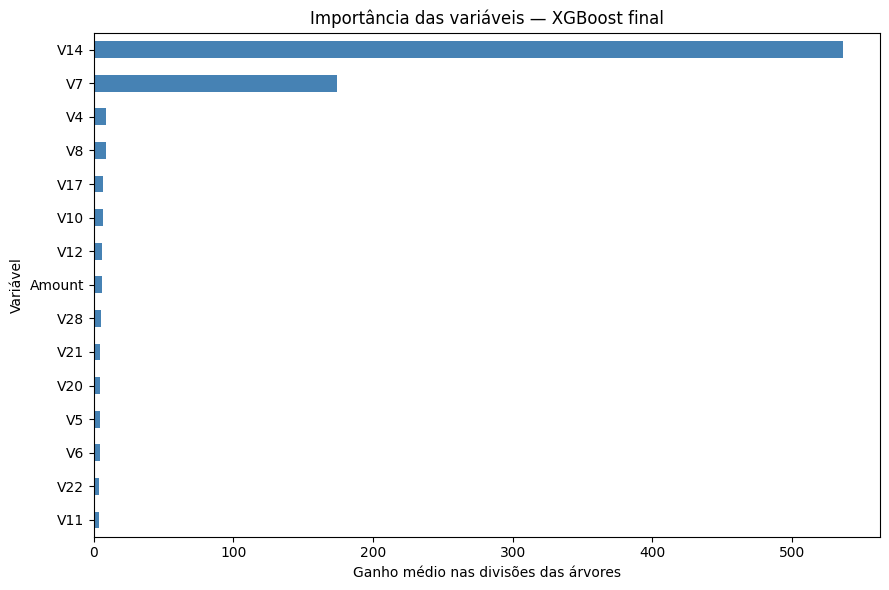

In [14]:
# Extrai a importância do modelo final, sem novo treinamento
ganhos = modelo_final.get_booster().get_score(
    importance_type="gain"
)

# Inclui também variáveis não utilizadas, com importância zero
importancias = pd.Series(
    {
        coluna: ganhos.get(coluna, 0.0)
        for coluna in X_train.columns
    },
    name="Ganho médio"
).sort_values(ascending=False)

print("15 variáveis com maior ganho médio:")
display(importancias.head(15).round(4).to_frame())

# Ordem crescente para colocar a maior barra no topo
top15 = importancias.head(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top15.plot.barh(ax=ax, color="steelblue")

ax.set_title("Importância das variáveis — XGBoost final")
ax.set_xlabel("Ganho médio nas divisões das árvores")
ax.set_ylabel("Variável")

plt.tight_layout()
plt.show()

Versão do SHAP: 0.52.0
Transações na amostra: 1000
Fraudes reais na amostra: 1


,Média do valor absoluto SHAP
V4,0.9777
V14,0.6687
V12,0.2838
V8,0.2497
V15,0.2443
V10,0.2376
V3,0.2352
V11,0.1866
V20,0.1739
V19,0.1729


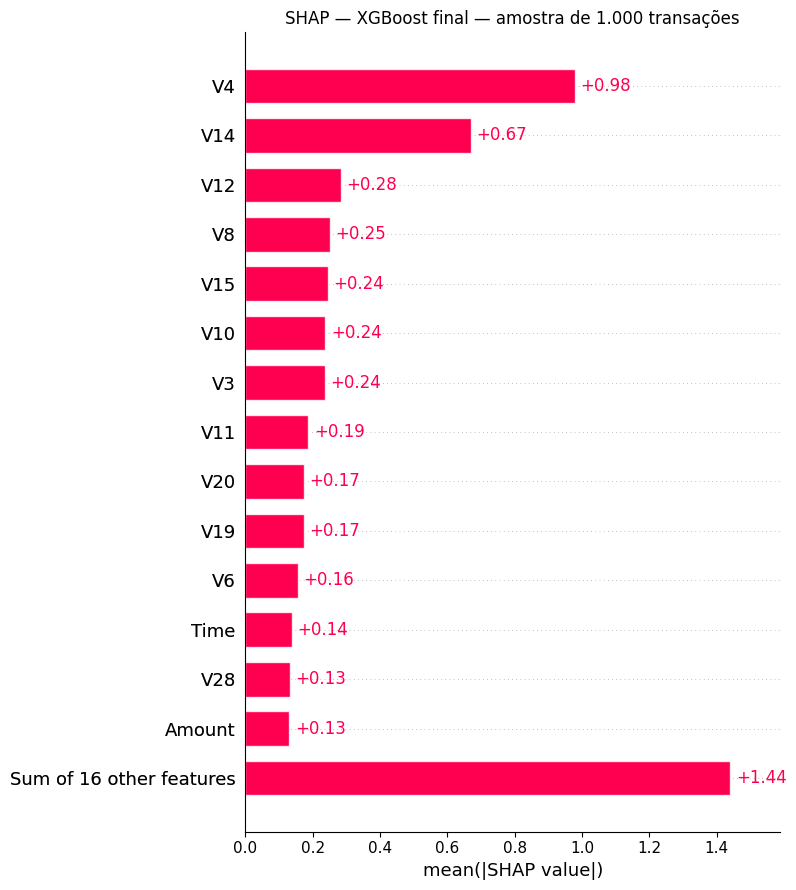

In [15]:
import shap

print("Versão do SHAP:", shap.__version__)

# Mantém a mesma amostra sorteada anteriormente
amostra_shap = X_test.sample(n=1000, random_state=42)

print("Transações na amostra:", len(amostra_shap))
print(
    "Fraudes reais na amostra:",
    int(y_test.loc[amostra_shap.index].sum())
)

# Usa as informações de treinamento armazenadas nas árvores
# Não fornecer "data" neste modo
explicador_shap = shap.TreeExplainer(
    modelo_final,
    feature_perturbation="tree_path_dependent",
    model_output="raw"
)

valores_shap = explicador_shap(amostra_shap)

importancia_shap = pd.Series(
    np.abs(valores_shap.values).mean(axis=0),
    index=amostra_shap.columns,
    name="Média do valor absoluto SHAP"
).sort_values(ascending=False)

display(importancia_shap.head(15).round(4).to_frame())

shap.plots.bar(valores_shap, max_display=15, show=False)
plt.title("SHAP — XGBoost final — amostra de 1.000 transações")
plt.tight_layout()
plt.show()

In [16]:
import sys
from importlib.metadata import version

print("Python:", sys.version.split()[0])

pacotes = [
    "pandas",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "imbalanced-learn",
    "xgboost",
    "shap"
]

versoes_ambiente = pd.DataFrame({
    "Biblioteca": pacotes,
    "Versão": [version(pacote) for pacote in pacotes]
})

display(versoes_ambiente)

print("\nSemente utilizada: 42")
print("Ambiente: Google Colab")

Python: 3.13.15


,Biblioteca,Versão
0,pandas,2.2.3
1,numpy,2.1.3
2,matplotlib,3.10.0
3,scikit-learn,1.6.1
4,imbalanced-learn,0.14.2
5,xgboost,3.4.1
6,shap,0.52.0



Semente utilizada: 42
Ambiente: Google Colab


## Conclusões do experimento

O projeto comparou modelos de classificação supervisionada para identificar transações fraudulentas em uma base pública desbalanceada.

A base original continha 284.807 registros, incluindo 492 fraudes, sem valores ausentes. Foram identificadas 1.081 repetições completas. Para o experimento, manteve-se a primeira ocorrência de cada linha em uma cópia de trabalho, preservando a base original. A cópia ficou com 283.726 registros e 473 fraudes.

Os dados foram divididos em aproximadamente 60% para treino, 20% para validação e 20% para teste, com estratificação por classe e semente fixa.

### Principais aprendizados

- A referência que sempre previa “não fraudulenta” apresentou alta acurácia, mas não detectou nenhuma fraude.
- Undersampling e SMOTE aumentaram o recall da regressão logística na validação, porém produziram muitos falsos alarmes no limite padrão.
- A Random Forest apresentou uma relação mais favorável entre detecção e falsos alarmes que as versões reamostradas da regressão logística.
- A busca de configurações do XGBoost utilizou validação cruzada exclusivamente no treino, selecionando pela AP média.
- O limite de decisão do XGBoost selecionado foi ajustado pelo maior F1 na validação, sem utilizar o teste.

### Resultado final no teste reservado

O XGBoost selecionado utilizou 100 árvores, profundidade máxima de 5 e `scale_pos_weight=1`. O limite escolhido foi aproximadamente 0,10628039, mantendo-se o valor completo na execução.

| Indicador | Resultado |
|---|---:|
| Transações avaliadas | 56.746 |
| Fraudes existentes | 95 |
| Fraudes detectadas | 73 |
| Fraudes não detectadas | 22 |
| Falsos alarmes | 8 |
| Precisão | 90,12% |
| Recall | 76,84% |
| F1 | 0,8295 |
| Average Precision (AP) | 0,8140 |
| ROC AUC | 0,9698 |

O desempenho no teste foi inferior ao observado na validação em algumas métricas. Os resultados foram registrados sem reajustar o modelo ou o limite após essa avaliação.

### Explicabilidade e limitações

A importância por ganho médio destacou V14 e V7. A análise SHAP destacou V4 e V14 em uma amostra aleatória de 1.000 transações de teste, contendo somente uma fraude. Portanto, esse resumo reflete principalmente previsões de transações não fraudulentas.

Após uma limitação de execução no modo `interventional`, o SHAP foi calculado com `tree_path_dependent`, sem alterar o modelo. As contribuições foram expressas em log-odds, não em porcentagens de probabilidade. Importância e contribuição não demonstram causalidade.

Não foi atribuído significado de negócio às variáveis V1–V28. Também não foi possível comprovar que as linhas idênticas representavam erros de registro, pois não havia identificador único de transação.

A divisão aleatória não simula uma avaliação cronológica de transações futuras. O teste contém apenas 95 fraudes, limitando a precisão das estimativas. Não foram avaliados custos financeiros dos erros, capacidade operacional de investigação ou desempenho em produção.

Este é um projeto educacional, não um sistema antifraude pronto para uso operacional.

## Autor

Antony Kennedy Ribeiro de Araújo  
GitHub: [AntKennedy000](https://github.com/AntKennedy000)